# Chromosome, Replicate 1 Scripting

Create a script to run the deconvolution on each replicate. This notebook will test the script.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
from pipeline.fit_replication_profiles import main
from src.utils import mkdir_safe

output_directory = "output/prototype_pipeline_subset_stage2/"


In [58]:
from pipeline.fit_replication_profiles import main as fit_replication_profile
from src.utils import print_fl
from src.config import load_default_chrom_configs
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.optimize_H import create_bounds_params_from_config

cold_start = False
chrom = 4
replicate = 1
num_epochs = 1
config = None
deconvolve_stage = 2

np.random.seed(123)

replication_deconvolver = fit_replication_profile(chrom=chrom, replicate=replicate, num_epochs=num_epochs, 
    output_directory=output_directory, deconvolve_stage=2)


Loading initial cell cycle parameters from CLOCCS fits.
Shifting mu0, gamma1, and gamma2, for alpha...
Omit windows with less than 75% read coverage.
No subset, full parameter updates
Running initial iterations...
Warm start config, N, F, and B from directory: output/prototype_pipeline_subset_stage2/
Deconvolving 702 regions
Initializing B using timepoint 0
[0] 00:00:00.352, rn=0.007085700253233957
[1] 00:00:00.727, rn=0.0039574855293570904
[2] 00:00:01.094, rn=0.003476610231449463
[3] 00:00:01.453, rn=0.003318198698178822
[4] 00:00:01.822, rn=0.003256988319075963
[5] 00:00:02.206, rn=0.0032208778458481663
[6] 00:00:02.669, rn=0.0032052301996125217
[7] 00:00:03.036, rn=0.003201015622446207
[8] 00:00:03.412, rn=0.003199263774693654
[9] 00:00:03.880, rn=0.003198376351343396
[10] 00:00:04.249, rn=0.003198148718093958
[11] 00:00:04.611, rn=0.00319790075523754
[12] 00:00:04.988, rn=0.003197898949698122
[13] 00:00:05.360, rn=0.003197898949250305
[14] 00:00:05.724, rn=0.0031978989492501817
[1

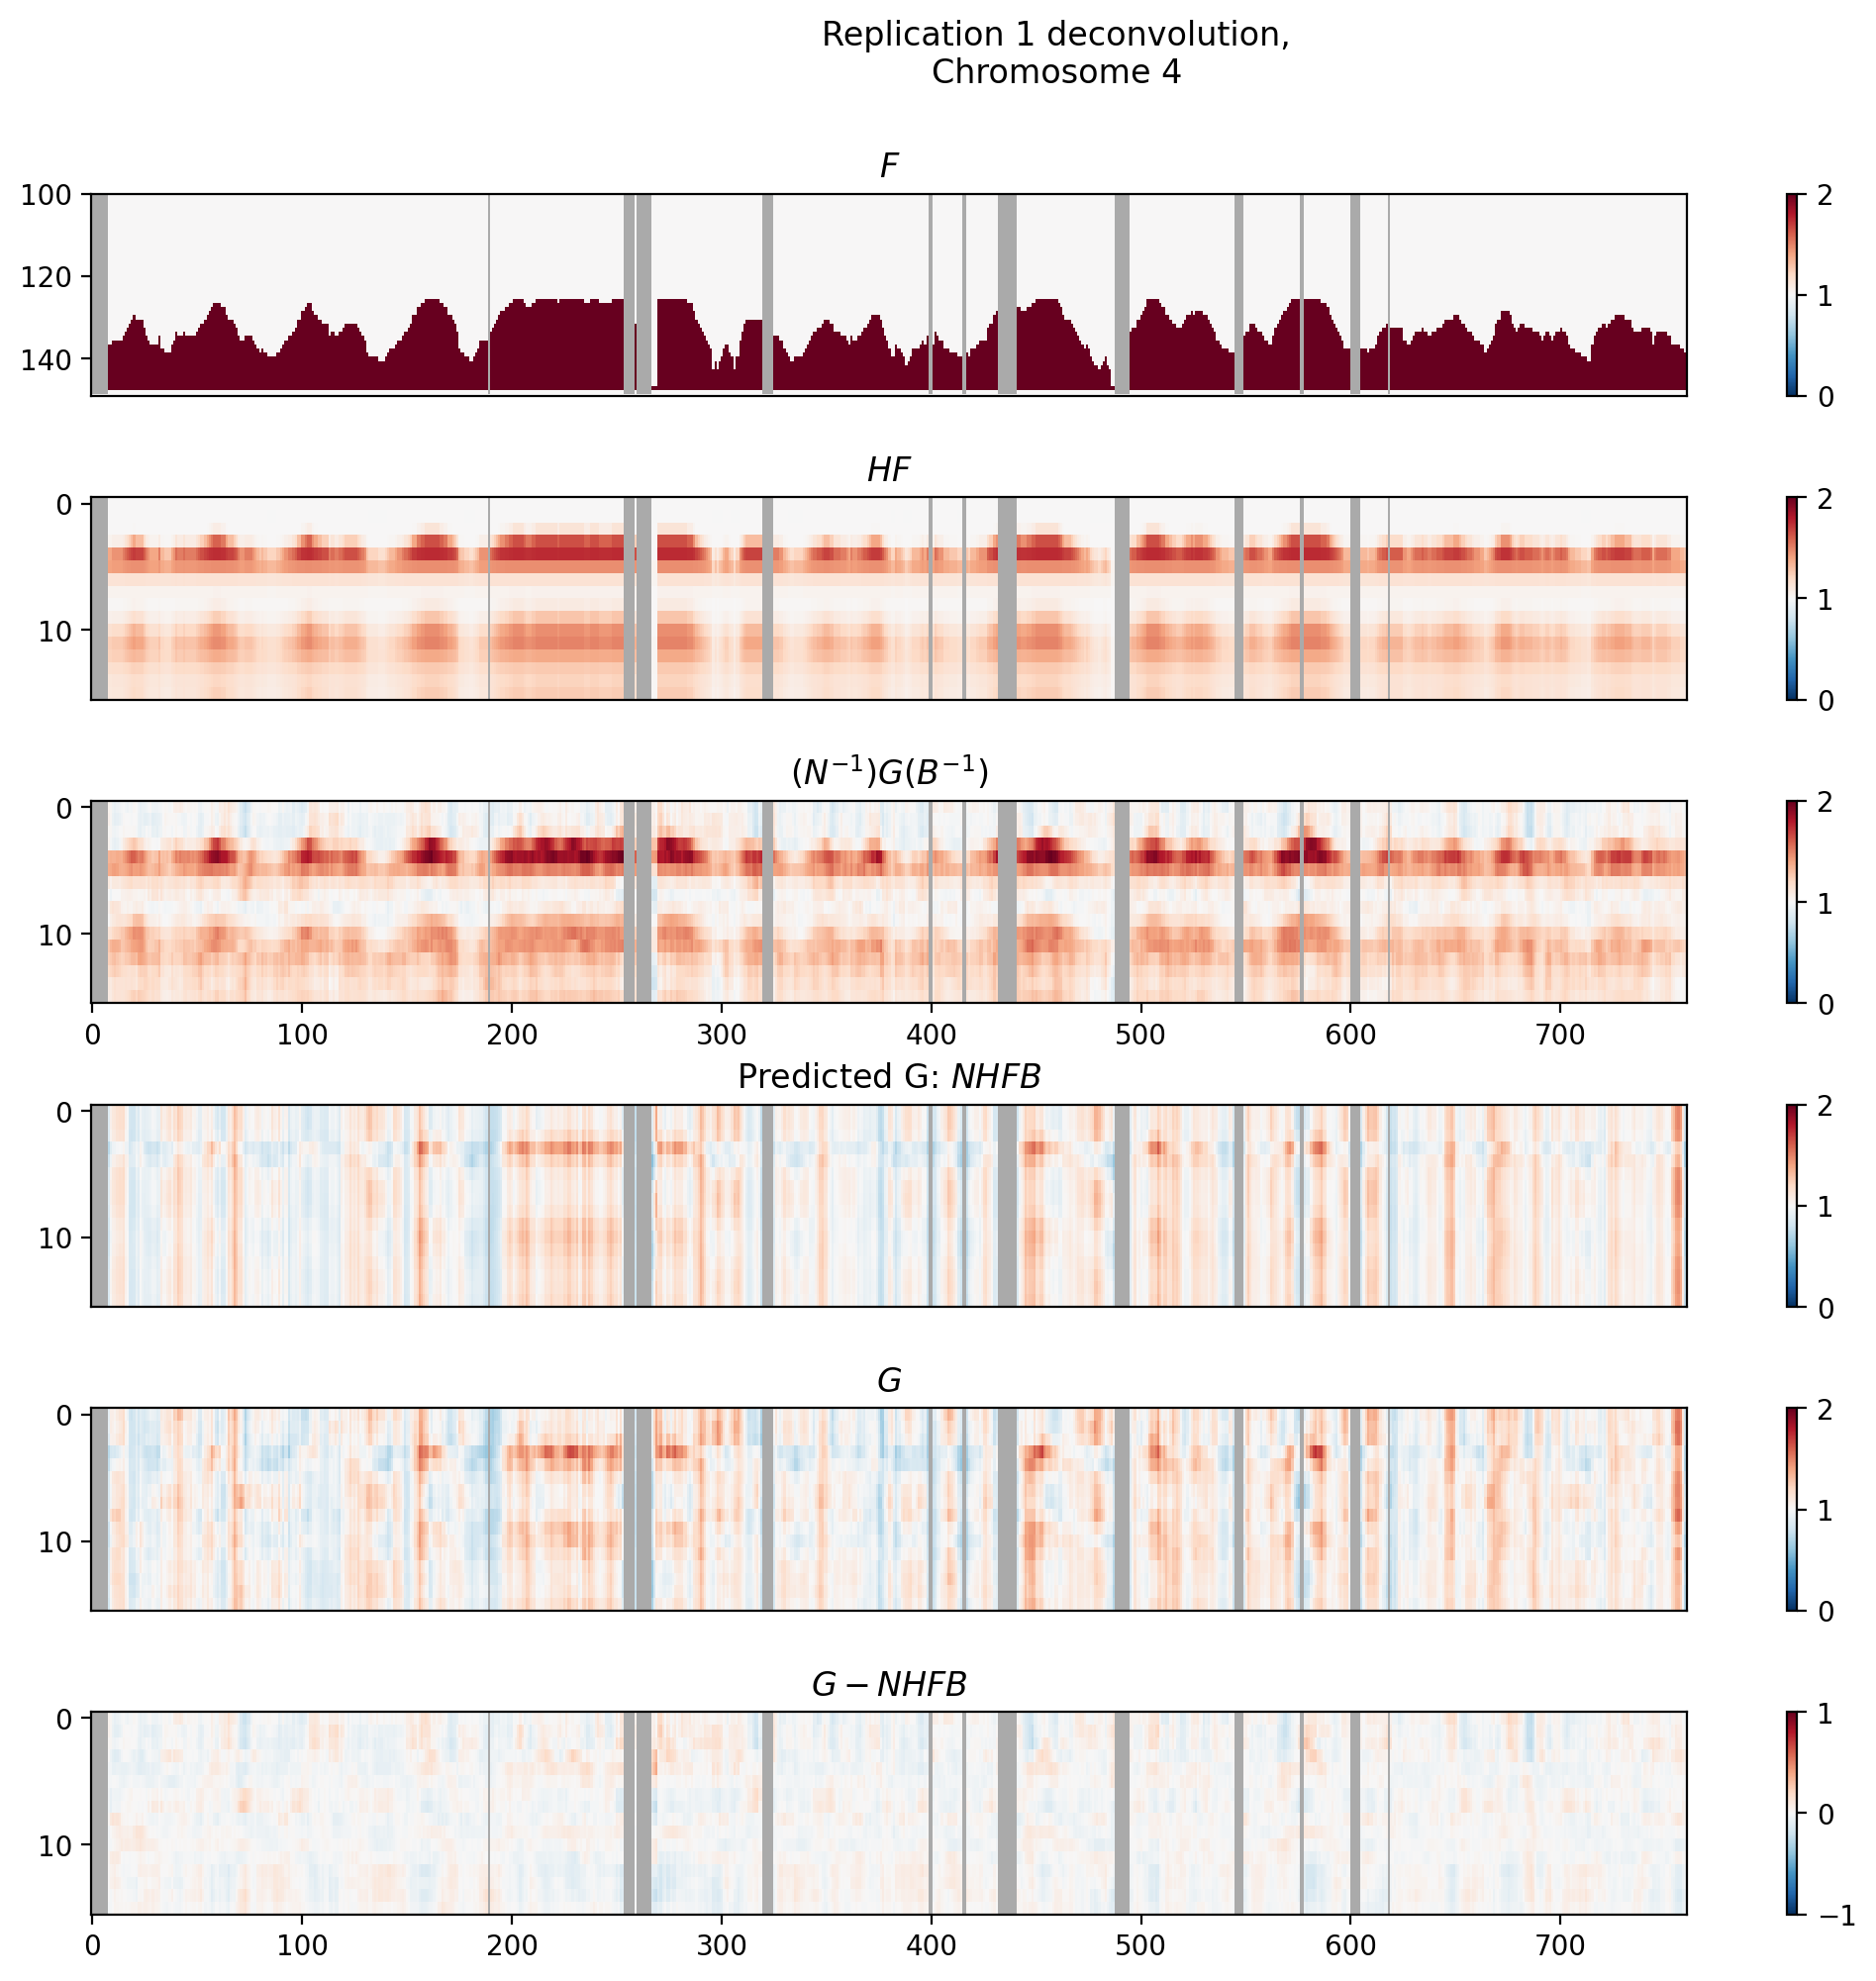

In [61]:
# Debug this, the model is not initializing properly from the parameters space.
fig = replication_deconvolver.plot_heatmaps()

In [93]:
# from pipeline.fit_replication_profiles import run_epochs

# # Run the optimizer
# update_params_df, Hs, Fs, Ns, Bs = run_epochs(replication_deconvolver, bounds_df,
#     1)

In [107]:
replication_deconvolver.config.update_timepoints()
replication_deconvolver.config.calculate_H()
replication_deconvolver.iterative_deconvolution_updates(5,
    initial_B=replication_deconvolver.B, initial_N=replication_deconvolver.N)

[0] 00:00:00.342, rn=0.0031641675577830297
[1] 00:00:00.698, rn=0.003123425147666305
[2] 00:00:01.073, rn=0.003123440221473438
[3] 00:00:01.430, rn=0.0031234402239940784
[4] 00:00:01.768, rn=0.003123440223994498


In [108]:
from src.optimize_H import ParameterOptimizer

optimizer = ParameterOptimizer(
    init_params_df=bounds_df,
    config=replication_deconvolver.config,
    N=replication_deconvolver.N,
    F=replication_deconvolver.F,
    B=replication_deconvolver.B,
    G=replication_deconvolver.G
)

In [109]:
replication_deconvolver.config.params_dic
#replication_deconvolver.plot_heatmaps()

{'mu0': 13.0259486257218,
 'delta': 8.1805,
 'sigma0': 4.274665303309875,
 'sigmav': 0.1424,
 'lambda': 68.1914,
 'gamma1': 0.4530754912466265,
 'gamma2': 1.0,
 'halted': 0.2245,
 'alpha': 0}

In [110]:
optimizer.compute_loss(None)

0.003123440223994498

In [112]:
params = [13.02594863, 8.1805, 4.2746653, 0.1424, 68.1914, 0.45307549, 1., 0.2245]

In [116]:
from src.RealDataReplication import compute_rn

F = optimizer.F
G = optimizer.G
N = optimizer.N
B = optimizer.B
H = optimizer.config.calculate_H()

In [117]:
compute_rn(N, H, F, B, G)

0.003123440223994498

In [115]:
optimizer.compute_loss(params)

[13.02594863, 8.1805, 4.2746653, 0.1424, 68.1914, 0.45307549, 1.0, 0.2245]


ValueError: 

In [111]:
optimizer.optimize(maxiter=100, verbose=True)

[13.02594863  8.1805      4.2746653   0.1424     68.1914      0.45307549
  1.          0.2245    ]


ValueError: 